<a href="https://colab.research.google.com/github/Kishanmvs/Data-Mining-Project/blob/main/Module_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODULE 2: Data Understanding & Preprocessing Pipeline
**BCI606 — Data Mining Mini Project**  
**Domain: Global Space Exploration Analytics**  
**Dataset: Global Space Exploration Dataset (3,000 missions, 2000–2025)**

---

### Why This Module Matters

In space mission analytics, preprocessing is **not a formality** — it is the most critical step. The raw dataset contains:

- **High-cardinality string identifiers** (`Mission Name`, `Launch Site`) that must be dropped or engineered into meaningful features
- **Multi-valued fields** (`Collaborating Countries`) that need to be parsed and transformed into numeric signals
- **Mixed scales** (Budget in billions vs. Duration in days vs. Success Rate as a percentage) requiring normalization
- **A continuous target** (`Success Rate %`) that must be binarized into a classification label

Every decision below is justified with the underlying math.


## Step 0: Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings, os

warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# ── Output directory for saved files ─────────────────────────────────────────
os.makedirs("datasets", exist_ok=True)
print("Setup complete. Output folder: datasets/")


Setup complete. Output folder: datasets/


## Step 1: Load Data & Initial Inspection



In [ ]:
# FIX: Load from working directory, not from datasets/ subfolder
df = pd.read_csv("Global_Space_Exploration_Dataset.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn data types:")
display(df.dtypes.to_frame("dtype"))
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nBasic statistics:")
display(df.describe())


Dataset shape: (3000, 12)

Column data types:


,dtype
Country,object
Year,int64
Mission Name,object
Mission Type,object
Launch Site,object
Satellite Type,object
Budget (in Billion $),float64
Success Rate (%),int64
Technology Used,object
Environmental Impact,object



First 5 rows:


,Country,Year,Mission Name,Mission Type,Launch Site,Satellite Type,Budget (in Billion $),Success Rate (%),Technology Used,Environmental Impact,Collaborating Countries,Duration (in Days)
0,China,2008,Sharable tertiary superstructure,Manned,Sheilatown,Communication,16.20,90,Nuclear Propulsion,Medium,"France, UK, Russia",112
1,Japan,2018,Re-engineered composite flexibility,Manned,New Ericfurt,Communication,29.04,99,Solar Propulsion,High,"Germany, Israel",236
2,Israel,2013,Reactive disintermediate projection,Manned,Port Kaitlynstad,Communication,28.73,54,AI Navigation,Medium,"China, Israel, USA",238
3,UAE,2010,Grass-roots 6thgeneration implementation,Unmanned,Mariastad,Spy,37.27,58,Traditional Rocket,Low,USA,186
4,India,2006,Balanced discrete orchestration,Manned,North Jasonborough,Weather,18.95,91,Solar Propulsion,Medium,"Israel, China, India",277



Basic statistics:


,Year,Budget (in Billion $),Success Rate (%),Duration (in Days)
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2012.471000,25.428917,74.985000,181.483000
std,7.437177,14.108438,14.945252,104.983822
min,2000.000000,0.530000,50.000000,1.000000
25%,2006.000000,12.977500,62.000000,91.000000
50%,2012.000000,25.495000,75.000000,180.000000
75%,2019.000000,37.597500,88.000000,272.000000
max,2025.000000,49.970000,100.000000,365.000000


## Step 2: Attribute Type Identification

Data Mining distinguishes attribute types because different algorithms require different mathematical operations:

| Type | Definition | Valid Operations | Example |
|---|---|---|---|
| **Nominal** | Unordered categories | Equality (==) only; Mode | Country, Mission Type |
| **Ordinal** | Ordered categories | Median meaningful; mean is not | Environmental Impact |
| **Numeric (Ratio)** | Continuous, meaningful zero | +, −, ×, ÷; Mean, Variance, Std | Budget, Duration |
| **Multi-valued** | One cell = list of values | Must be parsed first | Collaborating Countries |


In [ ]:
attribute_types = {
    # Identifiers — dropped before modelling
    'Mission Name':             'String Identifier              → DROP (near-unique, leakage risk)',
    'Launch Site':              'High-Cardinality Nominal       → DROP (2,702 unique values)',
    # Temporal
    'Year':                     'Numeric (Ratio / Temporal)     → Engineer into mission_era bins',
    # Nominal (unordered)
    'Country':                  'Nominal (10 categories)        → One-Hot Encode',
    'Mission Type':             'Binary Nominal (Manned/Unmanned) → Binary Encode (1/0)',
    'Satellite Type':           'Nominal (5 categories)         → One-Hot Encode',
    'Technology Used':          'Nominal (5 categories)         → One-Hot Encode',
    # Ordinal (ordered)
    'Environmental Impact':     'Ordinal (Low < Medium < High)  → Label Encode as 0 / 1 / 2',
    # Multi-valued
    'Collaborating Countries':  'Multi-valued Nominal           → Parse → collab_count (Numeric)',
    # Numeric (continuous ratio scale)
    'Budget (in Billion $)':    'Numeric Ratio (0.53 – 49.97)   → Z-Score Normalize',
    'Duration (in Days)':       'Numeric Ratio (1 – 365)        → Z-Score Normalize',
    # Target
    'Success Rate (%)':         'Numeric Ratio → TARGET         → Binarize → is_high_success',
}

print(f"{'Attribute':35s}  Strategy")
print("-" * 85)
for col, atype in attribute_types.items():
    print(f"  {col:33s}  {atype}")


Attribute                            Strategy
-------------------------------------------------------------------------------------
  Mission Name                       String Identifier              → DROP (near-unique, leakage risk)
  Launch Site                        High-Cardinality Nominal       → DROP (2,702 unique values)
  Year                               Numeric (Ratio / Temporal)     → Engineer into mission_era bins
  Country                            Nominal (10 categories)        → One-Hot Encode
  Mission Type                       Binary Nominal (Manned/Unmanned) → Binary Encode (1/0)
  Satellite Type                     Nominal (5 categories)         → One-Hot Encode
  Technology Used                    Nominal (5 categories)         → One-Hot Encode
  Environmental Impact               Ordinal (Low < Medium < High)  → Label Encode as 0 / 1 / 2
  Collaborating Countries            Multi-valued Nominal           → Parse → collab_count (Numeric)
  Budget (in Billion $)

## Step 3: Target Variable Creation — Binarization

The raw target `Success Rate (%)` is continuous (50–100). For binary classification we apply:

$$\text{is\_high\_success} = \begin{cases} 1 & \text{if Success Rate} \geq 70\% \\ 0 & \text{otherwise (At-Risk)} \end{cases}$$

**Threshold rationale (70%):**  
- The median success rate is ~75%. A 70% cut gives a ~60/40 class split — mild imbalance, manageable with SMOTE.  
- Domain context: missions below 70% historically face budget overruns, partial failures, or crew-safety reviews.


In [ ]:
THRESHOLD = 70
df['is_high_success'] = (df['Success Rate (%)'] >= THRESHOLD).astype(int)

class_counts = df['is_high_success'].value_counts()
print(f"Threshold: Success Rate >= {THRESHOLD}%")
print(f"  High Success (1): {class_counts.get(1, 0):,}  ({class_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"  At-Risk      (0): {class_counts.get(0, 0):,}  ({class_counts.get(0,0)/len(df)*100:.1f}%)")
print(f"  Class Ratio:      {class_counts.get(1,0)/class_counts.get(0,0):.2f} : 1")


Threshold: Success Rate >= 70%
  High Success (1): 1,802  (60.1%)
  At-Risk      (0): 1,198  (39.9%)
  Class Ratio:      1.50 : 1


## Step 4: Central Tendencies & Dispersion

For numeric features we compute the following summary statistics:

| Statistic | Formula | Sensitivity |
|---|---|---|
| Mean (μ) | $\frac{1}{N}\sum x_i$ | Sensitive to outliers |
| Median | Middle value | Robust to outliers |
| Variance (σ²) | $\frac{1}{N}\sum(x_i - \mu)^2$ | Spread in squared units |
| Std Dev (σ) | $\sqrt{\sigma^2}$ | Spread in original units |
| Skewness | $E[(X-\mu)^3]/\sigma^3$ | Asymmetry of distribution |
| Kurtosis | $E[(X-\mu)^4]/\sigma^4 - 3$ | Tail heaviness |


In [ ]:
numeric_cols = ['Budget (in Billion $)', 'Duration (in Days)', 'Success Rate (%)']

stats_df = df[numeric_cols].describe().T
stats_df['variance'] = df[numeric_cols].var()
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()

print("Descriptive Statistics (Numeric Features):")
display(stats_df[['mean', '50%', 'std', 'variance', 'skewness', 'kurtosis']].round(4))

print("\nCategorical Feature Modes:")
for col in ['Country', 'Mission Type', 'Satellite Type', 'Technology Used', 'Environmental Impact']:
    mode_val = df[col].mode()[0]
    freq     = df[col].value_counts().iloc[0]
    print(f"  {col:28s}  Mode: {mode_val:<25s}  (Freq: {freq})")


Descriptive Statistics (Numeric Features):


,mean,50%,std,variance,skewness,kurtosis
Budget (in Billion $),25.4289,25.495,14.1084,199.0480,-0.0073,-1.1872
Duration (in Days),181.4830,180.000,104.9838,11021.6029,0.0121,-1.1915
Success Rate (%),74.9850,75.000,14.9453,223.3606,0.0017,-1.2408



Categorical Feature Modes:
  Country                       Mode: China                      (Freq: 322)
  Mission Type                  Mode: Manned                     (Freq: 1528)
  Satellite Type                Mode: Research                   (Freq: 649)
  Technology Used               Mode: Traditional Rocket         (Freq: 650)
  Environmental Impact          Mode: Medium                     (Freq: 1032)


## Step 5: Missing Value Analysis

In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Percent (%)': missing_pct})

if missing.sum() > 0:
    print("Columns with missing values:")
    display(missing_report[missing_report['Missing Count'] > 0])
else:
    print("[OK] No missing values detected in any column.")
    display(missing_report)


[OK] No missing values detected in any column.


,Missing Count,Percent (%)
Country,0,0.0
Year,0,0.0
Mission Name,0,0.0
Mission Type,0,0.0
Launch Site,0,0.0
Satellite Type,0,0.0
Budget (in Billion $),0,0.0
Success Rate (%),0,0.0
Technology Used,0,0.0
Environmental Impact,0,0.0


## Step 6: Drop High-Cardinality Identifiers & Raw Target

| Column | Reason for Dropping |
|---|---|
| `Mission Name` | ~2,996 unique values in 3,000 rows — essentially an ID. Including it causes **data leakage** (model memorises names) and cannot generalise. |
| `Launch Site` | 2,702 unique values. One-Hot encoding would create ~2,702 near-empty binary columns (>99% zeros), dominating the feature space with noise. |
| `Success Rate (%)` | Already encoded into `is_high_success`. Retaining the raw form would be direct target leakage. |


In [ ]:
cols_to_drop = ['Mission Name', 'Launch Site', 'Success Rate (%)']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped: {cols_to_drop}")
print(f"Remaining columns ({df.shape[1]}): {list(df.columns)}")


Dropped: ['Mission Name', 'Launch Site', 'Success Rate (%)']
Remaining columns (10): ['Country', 'Year', 'Mission Type', 'Satellite Type', 'Budget (in Billion $)', 'Technology Used', 'Environmental Impact', 'Collaborating Countries', 'Duration (in Days)', 'is_high_success']


## Step 7: Feature Engineering

Two new features are derived from existing columns:

**A) `collab_count`** — parsed from `Collaborating Countries`  
The raw value is a comma-separated string (e.g. `"France, UK, Russia"`).  
Formula: `collab_count = count of comma-separated tokens`  
Rationale: More collaborators → more shared resources AND more coordination overhead. The net effect on success is empirically testable.

**B) `mission_era`** — discretised from `Year`  
Space technology has generational shifts:
- Era 0 (2000–2009): Post-ISS, traditional rockets dominant  
- Era 1 (2010–2017): Commercial space rise, reusable rockets emerge  
- Era 2 (2018–2025): AI Navigation, lunar return programmes  

This is a **domain-aware temporal feature** that captures concept drift.


In [ ]:
# (A) Collaboration count
df['collab_count'] = df['Collaborating Countries'].apply(
    lambda x: len([c.strip() for c in str(x).split(',') if c.strip()])
)
df.drop(columns=['Collaborating Countries'], inplace=True)
print(f"collab_count — Min: {df['collab_count'].min()}, "
      f"Max: {df['collab_count'].max()}, "
      f"Mean: {df['collab_count'].mean():.2f}")

# (B) Mission era
def assign_era(year):
    if year <= 2009:  return 0   # Early era
    elif year <= 2017: return 1  # Mid era
    else:              return 2  # Modern era

df['mission_era'] = df['Year'].apply(assign_era)
df.drop(columns=['Year'], inplace=True)
print(f"\nmission_era distribution:")
print(df['mission_era'].value_counts().sort_index().rename({0:'Era 0 (2000-09)',
                                                            1:'Era 1 (2010-17)',
                                                            2:'Era 2 (2018-25)'}).to_string())
print(f"\nShape after feature engineering: {df.shape}")


collab_count — Min: 1, Max: 3, Mean: 1.98

mission_era distribution:
mission_era
Era 0 (2000-09)    1137
Era 1 (2010-17)     951
Era 2 (2018-25)     912

Shape after feature engineering: (3000, 10)


## Step 8: Encode Categorical Variables

Three strategies are used — chosen based on attribute type:

| Strategy | Applied To | Reason |
|---|---|---|
| **One-Hot Encoding** | `Country`, `Satellite Type`, `Technology Used` | Nominal — no ordering. `drop_first=True` avoids the dummy variable trap (multicollinearity). |
| **Binary Encoding** | `Mission Type` | Only 2 categories — a single 0/1 column suffices. One-Hot would create two perfectly collinear columns. |
| **Ordinal Encoding** | `Environmental Impact` | Natural order (Low < Medium < High) must be preserved. Allows k-NN to compute correct distances. |

**Dummy variable trap:** If $k-1$ binary columns are known, the $k$-th is determined automatically. Including it inflates the feature space and creates perfect multicollinearity.


In [ ]:
# (A) One-Hot Encoding for unordered nominal features
df = pd.get_dummies(df, columns=['Country', 'Satellite Type', 'Technology Used'],
                    drop_first=True)
print(f"One-Hot encoded: Country, Satellite Type, Technology Used")

# (B) Binary encoding for Mission Type
df['Mission Type'] = df['Mission Type'].map({'Manned': 1, 'Unmanned': 0})
print(f"Binary encoded:  Mission Type (Manned=1, Unmanned=0)")

# (C) Ordinal encoding for Environmental Impact
impact_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Environmental Impact'] = df['Environmental Impact'].map(impact_map)
print(f"Ordinal encoded: Environmental Impact (Low=0, Medium=1, High=2)")

print(f"\nShape after encoding: {df.shape}")
print(f"All columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i:02d}] {c}")


One-Hot encoded: Country, Satellite Type, Technology Used
Binary encoded:  Mission Type (Manned=1, Unmanned=0)
Ordinal encoded: Environmental Impact (Low=0, Medium=1, High=2)

Shape after encoding: (3000, 24)
All columns:
  [00] Mission Type
  [01] Budget (in Billion $)
  [02] Environmental Impact
  [03] Duration (in Days)
  [04] is_high_success
  [05] collab_count
  [06] mission_era
  [07] Country_France
  [08] Country_Germany
  [09] Country_India
  [10] Country_Israel
  [11] Country_Japan
  [12] Country_Russia
  [13] Country_UAE
  [14] Country_UK
  [15] Country_USA
  [16] Satellite Type_Navigation
  [17] Satellite Type_Research
  [18] Satellite Type_Spy
  [19] Satellite Type_Weather
  [20] Technology Used_Nuclear Propulsion
  [21] Technology Used_Reusable Rocket
  [22] Technology Used_Solar Propulsion
  [23] Technology Used_Traditional Rocket


## Step 9: Outlier Analysis (Report Only — Not Removing)

The **IQR method** flags values outside the fences:
$$\text{Lower} = Q_1 - 1.5 \times IQR \quad\quad \text{Upper} = Q_3 + 1.5 \times IQR$$

**Decision for space exploration: retain all outliers.**  
A \$49.97B budget is not an error — it represents a flagship programme (e.g., Artemis, ISS). A 1-day duration is a real sub-orbital flight.  
Removing outliers would eliminate scientifically important missions. Instead, Z-score normalisation reduces their *relative magnitude* while preserving them as meaningful data points.




In [ ]:
df_orig = pd.read_csv("Global_Space_Exploration_Dataset.csv")

# Compute collab_count on df_orig for the outlier report
df_orig['collab_count'] = df_orig['Collaborating Countries'].apply(
    lambda x: len([c.strip() for c in str(x).split(',') if c.strip()])
)

outlier_cols = ['Budget (in Billion $)', 'Duration (in Days)', 'collab_count']
outlier_records = {}
for col in outlier_cols:
    Q1  = df_orig[col].quantile(0.25)
    Q3  = df_orig[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_orig[col] < lower) | (df_orig[col] > upper)).sum()
    outlier_records[col] = {
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Lower Fence': round(lower, 2), 'Upper Fence': round(upper, 2),
        'Outlier Count': n_out,
        'Outlier %': round(n_out / len(df_orig) * 100, 2)
    }

display(pd.DataFrame(outlier_records).T)
print("\n[!] Decision: Outliers RETAINED — they represent real flagship missions.")


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
Budget (in Billion $),12.98,37.6,24.62,-23.95,74.53,0.0,0.0
Duration (in Days),91.00,272.0,181.00,-180.50,543.50,0.0,0.0
collab_count,1.00,3.0,2.00,-2.00,6.00,0.0,0.0



[!] Decision: Outliers RETAINED — they represent real flagship missions.


## Step 10: Normalization — Z-Score Scaling

Two primary methods compared:

| Method | Formula | Issue with this dataset |
|---|---|---|
| **Min-Max** | $X' = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$ | A single \$49.97B mission compresses all others into a narrow low-end range |
| **Z-Score** ✓ | $X' = \frac{X - \mu}{\sigma}$ | Centres at 0, unit variance. Outliers get large \|z\| but the rest is not compressed |

**Choice:** Z-Score (`StandardScaler`) for the three continuous numeric columns.  
Binary/ordinal-encoded features are **not scaled** — scaling would destroy their interpretability.


In [ ]:
cols_to_scale = ['Budget (in Billion $)', 'Duration (in Days)', 'collab_count']

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print(f"Applied StandardScaler (Z-Score) to: {cols_to_scale}")
print(f"\nPost-scaling verification (mean ≈ 0, std ≈ 1):")
display(df[cols_to_scale].describe().loc[['mean', 'std']].round(4))


Applied StandardScaler (Z-Score) to: ['Budget (in Billion $)', 'Duration (in Days)', 'collab_count']

Post-scaling verification (mean ≈ 0, std ≈ 1):


,Budget (in Billion $),Duration (in Days),collab_count
mean,0.0000,-0.0000,0.0000
std,1.0002,1.0002,1.0002


## Step 11: Class Imbalance Analysis & SMOTE

Class split: ~60% High Success vs ~40% At-Risk — a **mild ~1.5 : 1 imbalance**.  
Although less extreme than fraud detection (66 : 1), the minority class (At-Risk) is the most important for intervention planning.

**SMOTE — Synthetic Minority Over-sampling Technique:**  
For each minority sample $x_i$, find its $k$ nearest neighbours. Create a synthetic sample on the line segment between $x_i$ and a randomly chosen neighbour:
$$x_{\text{new}} = x_i + \lambda \cdot (x_{\text{neighbour}} - x_i), \quad \lambda \in [0, 1]$$

> ⚠️ **Critical:** SMOTE is applied **only to the training set**. Applying it to the full dataset would introduce synthetic points into the test set, inflating performance metrics (**data leakage**).



In [ ]:
print("Class Distribution (BEFORE resampling):")
class_counts = df['is_high_success'].value_counts()
print(f"  High Success (1): {class_counts.get(1, 0):>6,d}  ({class_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"  At-Risk      (0): {class_counts.get(0, 0):>6,d}  ({class_counts.get(0,0)/len(df)*100:.1f}%)")

# FIX: use get(0, 0) with an explicit zero-division guard instead of get(0, 1)
denom = class_counts.get(0, 0)
ratio_str = f"{class_counts.get(1,0)/denom:.2f}:1" if denom > 0 else "N/A (no At-Risk samples)"
print(f"  Imbalance Ratio: {ratio_str}")

X = df.drop(columns=['is_high_success'])
y = df['is_high_success']

# Train-test split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain / Test split: {X_train.shape[0]:,} train  /  {X_test.shape[0]:,} test  (stratified)")
print(f"Train At-Risk rate: {(1 - y_train.mean())*100:.1f}%")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nClass Distribution (AFTER SMOTE on training set):")
resampled_counts = pd.Series(y_train_resampled).value_counts()
print(f"  High Success (1): {resampled_counts.get(1, 0):>6,d}")
print(f"  At-Risk      (0): {resampled_counts.get(0, 0):>6,d}")
print(f"  Ratio: ~1:1 (balanced)  [OK]")


Class Distribution (BEFORE resampling):
  High Success (1):  1,802  (60.1%)
  At-Risk      (0):  1,198  (39.9%)
  Imbalance Ratio: 1.50:1

Train / Test split: 2,400 train  /  600 test  (stratified)
Train At-Risk rate: 39.9%

Class Distribution (AFTER SMOTE on training set):
  High Success (1):  1,442
  At-Risk      (0):  1,442
  Ratio: ~1:1 (balanced)  [OK]


## Step 12: Save Preprocessed Data

In [ ]:
train_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
train_resampled['is_high_success'] = y_train_resampled.values

test_set = pd.DataFrame(X_test, columns=X_test.columns)
test_set['is_high_success'] = y_test.values

train_resampled.to_csv("datasets/preprocessed_train.csv", index=False)
test_set.to_csv("datasets/preprocessed_test.csv",         index=False)
df.to_csv("datasets/preprocessed_full.csv",               index=False)

print("Saved:  datasets/preprocessed_train.csv  (SMOTE-balanced training set)")
print("Saved:  datasets/preprocessed_test.csv    (untouched test set)")
print("Saved:  datasets/preprocessed_full.csv    (full preprocessed, original balance)")


Saved:  datasets/preprocessed_train.csv  (SMOTE-balanced training set)
Saved:  datasets/preprocessed_test.csv    (untouched test set)
Saved:  datasets/preprocessed_full.csv    (full preprocessed, original balance)


## Step 13: Visualizations

Four plots are generated:
1. Class distribution before vs. after SMOTE
2. Budget and Duration distributions split by success class
3. Feature correlation matrix (heatmap)
4. Average success rate by country


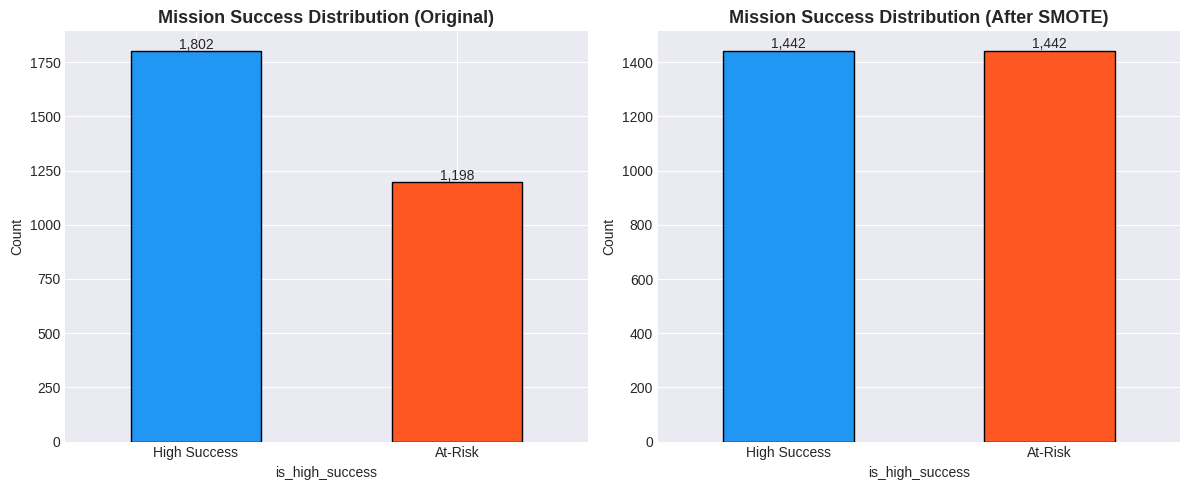

Saved: datasets/class_distribution.png


In [ ]:
# ── 13a: Class distribution before vs. after SMOTE ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

class_counts.reindex([1, 0]).plot(kind='bar', ax=axes[0],
    color=['#2196F3', '#FF5722'], edgecolor='black')
axes[0].set_title('Mission Success Distribution (Original)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['High Success', 'At-Risk'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10), ha='center')

resampled_counts.reindex([1, 0]).plot(kind='bar', ax=axes[1],
    color=['#2196F3', '#FF5722'], edgecolor='black')
axes[1].set_title('Mission Success Distribution (After SMOTE)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['High Success', 'At-Risk'], rotation=0)
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 10), ha='center')

plt.tight_layout()
plt.savefig("datasets/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datasets/class_distribution.png")


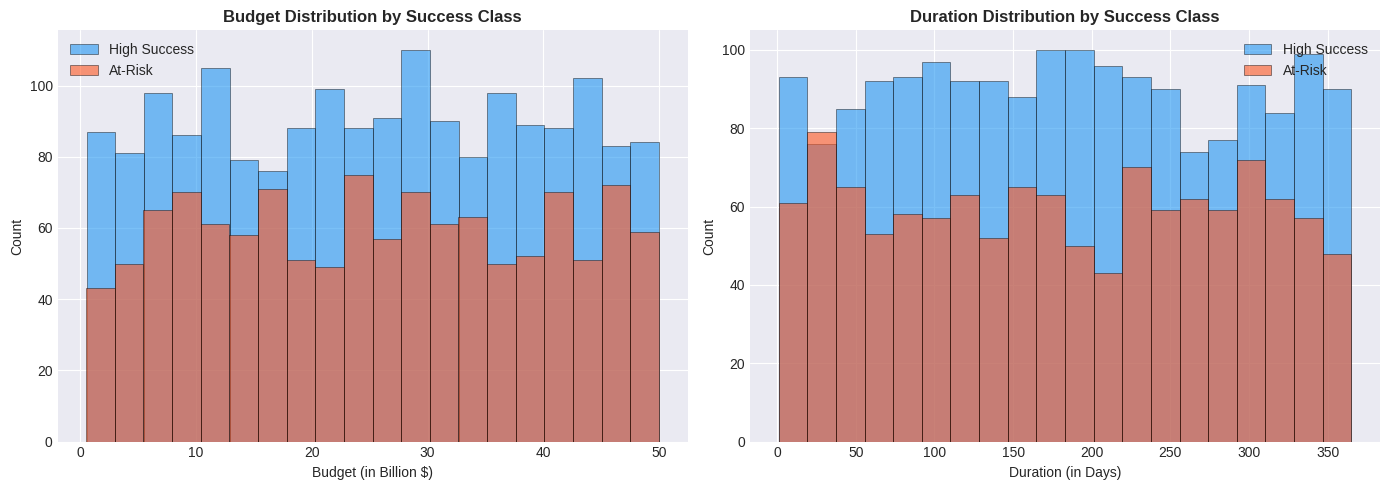

Saved: datasets/feature_distributions.png


In [ ]:
# ── 13b: Budget & Duration distributions by success class ──────────────────
# FIX: Reload df_orig using corrected path (same fix as Steps 1 & 9)
df_orig = pd.read_csv("Global_Space_Exploration_Dataset.csv")
df_orig['is_high_success'] = (df_orig['Success Rate (%)'] >= 70).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in [(1, '#2196F3'), (0, '#FF5722')]:
    subset = df_orig[df_orig['is_high_success'] == label]
    lbl    = 'High Success' if label == 1 else 'At-Risk'
    axes[0].hist(subset['Budget (in Billion $)'], bins=20, alpha=0.6,
                 color=color, label=lbl, edgecolor='black', linewidth=0.5)
    axes[1].hist(subset['Duration (in Days)'],    bins=20, alpha=0.6,
                 color=color, label=lbl, edgecolor='black', linewidth=0.5)

axes[0].set_title('Budget Distribution by Success Class',   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Budget (in Billion $)'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].set_title('Duration Distribution by Success Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Duration (in Days)');    axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout()
plt.savefig("datasets/feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datasets/feature_distributions.png")


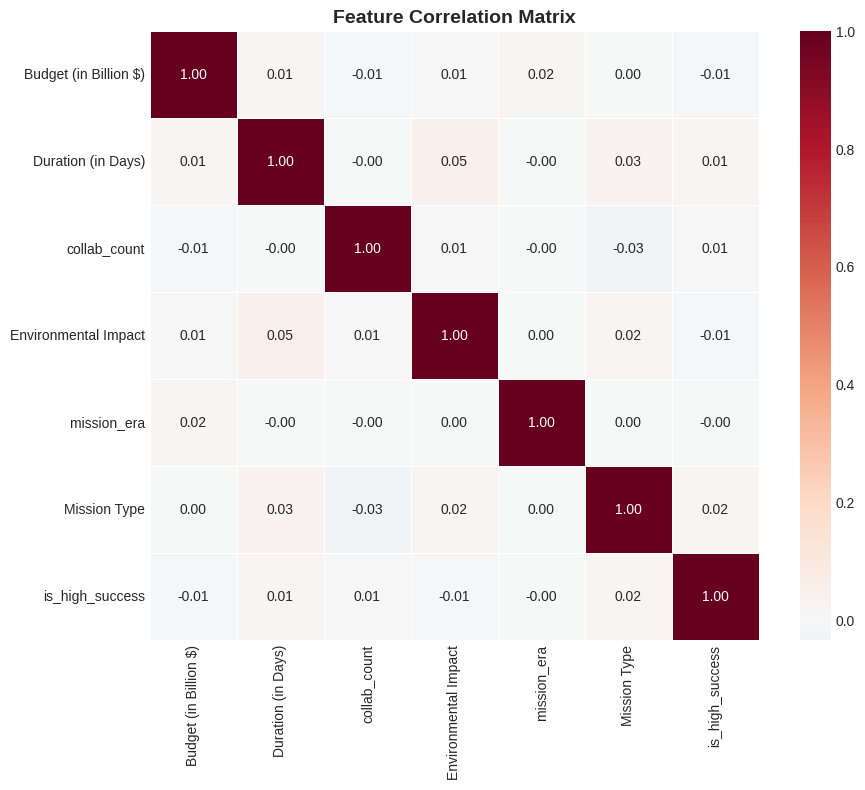

Saved: datasets/correlation_heatmap.png


In [ ]:
# ── 13c: Correlation heatmap ───────────────────────────────────────────────
corr_cols = ['Budget (in Billion $)', 'Duration (in Days)',
             'collab_count', 'Environmental Impact',
             'mission_era', 'Mission Type', 'is_high_success']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("datasets/correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datasets/correlation_heatmap.png")


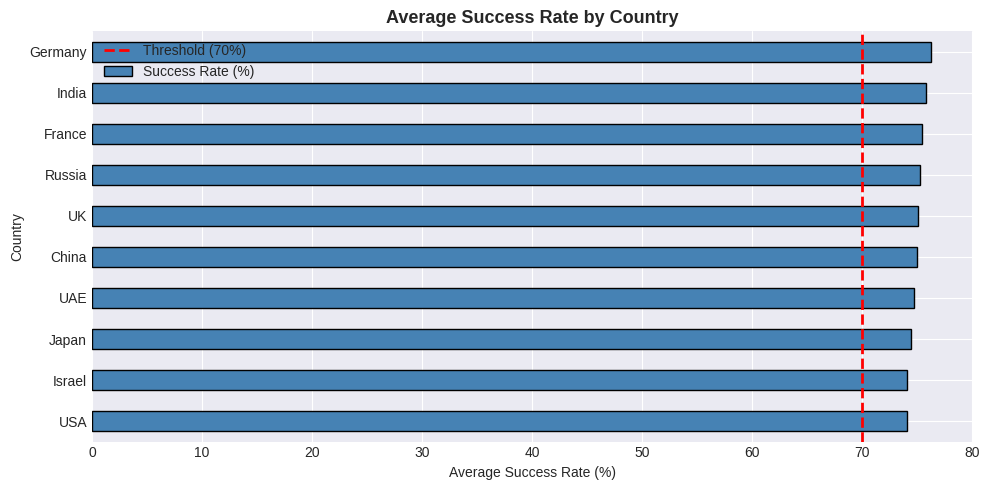

Saved: datasets/success_by_country.png


In [ ]:
# ── 13d: Average success rate by country ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
country_success = df_orig.groupby('Country')['Success Rate (%)'].mean().sort_values()
country_success.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Threshold (70%)')
ax.set_title('Average Success Rate by Country', fontsize=13, fontweight='bold')
ax.set_xlabel('Average Success Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig("datasets/success_by_country.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datasets/success_by_country.png")
